# Task 3 | Tương tác cao chưa đồng nghĩa với gắn bó sâu
**Customer Engagement Analysis · ITB / BI10 Round 01 · Synthetic Vietnam 2025**

Bài làm bám **BI10_ROUND01.pdf, trang PDF 11–12** (trang in 09–10), không theo số task trong case study.
Notebook giải thích bằng tiếng Việt; biểu đồ và bộ 4 slide đính kèm bằng tiếng Anh theo quy định nộp bài.

**Mạch phân tích:** xác nhận mẫu → phân bố điểm → độ sâu sử dụng kênh → độ rộng và nhịp giao dịch → giao điểm sức khỏe/tương tác → hành động có kiểm chứng.

| Yêu cầu chính thức | Phần trả lời | Sản phẩm |
|---|---|---|
| Phân bố điểm và tỷ lệ khách trong từng nhóm | 2 | Histogram + bảng nhóm theo khách/tháng |
| POS, QR, E-commerce, Mobile App, Recurring; trung bình tỷ trọng online | 3 | Ba thước đo adoption + đối chiếu online/digital |
| Khoảng category diversity và liên hệ với engagement | 4 | Phân bố rời rạc + tương quan |
| Khoảng recency, frequency và liên hệ với engagement | 4 | ECDF, boxplot, bảng min/Q1/median/Q3/max |
| Quy mô, chân dung high-health/low-engagement; lý do chọn ngưỡng | 5 | Nhóm tuyệt đối + nhóm tương đối + sensitivity |
| Biểu đồ phù hợp dữ liệu | 2–5 | Không dùng biểu đồ tròn cho nhóm quá nhỏ; không nối nhóm rời rạc |

**Nguyên tắc:** Không suy diễn nhân quả, không gọi vắng dữ liệu là churn. Không dùng điểm sức khỏe để phê duyệt/từ chối tín dụng, giảm hạn mức hoặc khóa tài khoản.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, Markdown

DATA = Path('../data')
OUT = Path('outputs')
CHART = OUT / 'charts'
OUT.mkdir(exist_ok=True)
CHART.mkdir(exist_ok=True)
BLUE, TEAL, RED, GRAY, INK = '#2a78d6', '#117f78', '#e34948', '#b4b5b6', '#182d3b'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelcolor': INK, 'text.color': INK, 'axes.axisbelow': True,
    'figure.facecolor': 'white', 'savefig.facecolor': 'white'})
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
TABLES = {}
NARRATIVE = []

def table(name, frame):
    TABLES[name] = frame.copy()
    frame.to_csv(OUT / f'{name}.csv', encoding='utf-8-sig')
    display(frame)

def say(text):
    NARRATIVE.append(text)
    display(Markdown(text))

def save(fig, name, source):
    fig.text(.01, .008, source, fontsize=8, color='#56616a')
    fig.tight_layout(rect=(0, .055, 1, 1))
    fig.savefig(CHART / f'{name}.png', dpi=180)
    fig.savefig(CHART / f'{name}.svg')
    plt.show()
    plt.close(fig)

## 1. Kiểm tra đầu vào và thống nhất mẫu số
Không lấy tổng số dòng làm tổng số khách. Bảng tháng nối với giao dịch bằng **consumer_id + tháng**, không chỉ consumer_id.
Đọc toàn bộ sổ giao dịch, chỉ chọn cột cần thiết để tiết kiệm bộ nhớ. Không cắt outlier vì đây là phân tích hành vi, không huấn luyện mô hình.
Từ điển định nghĩa recency là số ngày từ giao dịch cuối đến cuối tháng; online được quyết định bằng cờ, không tự gộp QR vào online.

In [2]:
dictionary = pd.read_excel(DATA / 'data_dictionary.xlsx', sheet_name=None)
display(dictionary['About'])
terms = ['engagement_score', 'engagement_segment', 'category_diversity',
         'transaction_recency_days', 'transaction_count', 'online_spend_ratio']
display(dictionary['Customer_Month'].set_index('column_name').loc[terms, ['definition_vi','allowed_values']])
cm = pd.read_csv(DATA / 'consumer_financial_health_engagement_2025.csv', parse_dates=['analysis_month'])
cols = ['transaction_id', 'activity_datetime', 'consumer_id', 'spending_category',
        'spend_amount_vnd', 'transaction_channel', 'online_transaction_flag']
tx = pd.read_csv(DATA / 'consumer_transactions_2025.csv', usecols=cols,
    dtype={'transaction_channel':'category','spending_category':'category'})
tx['activity_datetime'] = pd.to_datetime(tx['activity_datetime'])
tx['analysis_month'] = tx.activity_datetime.dt.to_period('M').dt.to_timestamp()
tx['day'] = tx.activity_datetime.dt.normalize()
tx['online_vnd'] = tx.spend_amount_vnd * tx.online_transaction_flag
tx['digital_vnd'] = tx.spend_amount_vnd.where(tx.transaction_channel.ne('POS'), 0)
keys = ['consumer_id', 'analysis_month']
recon = pd.DataFrame(tx.groupby(keys, observed=True).agg(
    raw_count=('transaction_id','size'), raw_spend=('spend_amount_vnd','sum'),
    raw_online=('online_vnd','sum'), raw_categories=('spending_category','nunique'),
    raw_days=('day','nunique'), last_transaction=('activity_datetime','max')))
audit = cm.merge(recon, on=keys, how='outer', validate='one_to_one', indicator=True)
# Calendar-day convention, independently recomputed from transaction timestamps.
audit['raw_recency'] = ((audit.analysis_month + pd.offsets.MonthEnd(0)) - audit.last_transaction.dt.normalize()).dt.days
checks = {
    'unique consumer-month key': not cm.duplicated(keys).any(),
    'unique transaction ID': tx.transaction_id.is_unique,
    'all raw and monthly keys match': audit['_merge'].eq('both').all(),
    'transaction counts reconcile': audit.transaction_count.eq(audit.raw_count).all(),
    'spend reconciles exactly': audit.total_spend_vnd.eq(audit.raw_spend).all(),
    'online spend reconciles exactly': audit.online_spend_vnd.eq(audit.raw_online).all(),
    'category diversity reconciles': audit.category_diversity.eq(audit.raw_categories).all(),
    'active days reconcile': audit.active_transaction_days.eq(audit.raw_days).all(),
    'calendar-day recency reconciles': audit.transaction_recency_days.eq(audit.raw_recency).all(),
    'no missing analytical fields': cm.drop(columns='next_month_low_health_flag').notna().all().all(),
    'timestamps inside 2025': tx.activity_datetime.dt.year.eq(2025).all(),
    'nonnegative spending': tx.spend_amount_vnd.ge(0).all(),
    'scores inside 0-100': bool(np.all((cm[['engagement_score','financial_health_score']].to_numpy() >= 0) & (cm[['engagement_score','financial_health_score']].to_numpy() <= 100))),
    'online ratio reconciles': np.allclose(cm.online_spend_ratio, cm.online_spend_vnd / cm.total_spend_vnd),
}
table('01_quality_checks', pd.Series(checks, name='passed').to_frame())
# A failed check must remain visible, not silently repaired.
assert all(checks.values()), 'Inspect failed quality checks before interpreting results.'
coverage = pd.Series(cm.groupby('consumer_id').size(), name='observed_months')
cm = cm.join(coverage, on='consumer_id')
full_cm = pd.DataFrame(cm[cm.observed_months.eq(12)]).copy()
annual = pd.DataFrame(cm.groupby('consumer_id').agg(
    observed_months=('analysis_month','size'), age=('age','min'), gender=('gender','first'),
    occupation=('occupation','first'), province=('province_city','first'),
    health=('financial_health_score','mean'), engagement=('engagement_score','mean'),
    frequency=('transaction_count','mean'), active_days=('active_transaction_days','mean'),
    diversity=('category_diversity','mean'), recency=('transaction_recency_days','mean'),
    online_month_mean=('online_spend_ratio','mean'), online_vnd=('online_spend_vnd','sum'),
    total_vnd=('total_spend_vnd','sum'), spend_income=('spend_to_income_ratio','mean'),
    essential_share=('essential_spend_ratio','mean')))
annual['online_year_share'] = annual.online_vnd / annual.total_vnd
full = pd.DataFrame(annual[annual.observed_months.eq(12)]).copy()
dec = cm[cm.analysis_month.eq('2025-12-01')].copy()
table('02_coverage', coverage.value_counts().sort_index().rename('customers').to_frame())
table('03_monthly_coverage', cm.groupby('analysis_month').agg(customers=('consumer_id','nunique'), mean_engagement=('engagement_score','mean')))
table('04_partial_history_comparison', cm.groupby(cm.observed_months.eq(12))[
    ['transaction_count','active_transaction_days','engagement_score','financial_health_score']].median().rename(index={True:'12 months',False:'1-2 months'}))
say(f'''### Dữ liệu đã được kiểm tra
- **{len(tx):,} giao dịch, {len(cm):,} khách hàng-tháng, {len(annual):,} khách duy nhất.**
- **{len(full)} khách đủ 12 tháng** dùng cho so sánh hành vi thường xuyên, nhất quán với Task 2; **{len(annual)-len(full)} khách ít lịch sử** vẫn xuất hiện trong phân tích toàn mẫu và danh sách theo tháng, không bị xóa.
- Tháng 12 quan sát được **{len(dec)} khách**; {len(annual)-len(dec)} khách không có dòng tháng 12. Đây là thiếu quan sát, không phải nhãn rời bỏ.
- {sum(checks.values())}/{len(checks)} kiểm tra đạt. Nhãn `next_month_low_health_flag` có {cm.next_month_low_health_flag.isna().sum()} ô thiếu và **không được sử dụng** trong Task 3.
- Từ điển không cung cấp công thức engagement. Những liên hệ với điểm dưới đây là mô tả, có thể trùng với thành phần tạo điểm; không gọi là tác động nhân quả.''')

,field,value
0,Dataset,Consumer Financial Health & Engagement 2025 (s...
1,Grains,Transaction-level + consumer-month
2,Coverage,Calendar year 2025
3,Join key,consumer_id
4,Currency,VND
5,Synthetic disclaimer,"All identities, geography, merchants, income, ..."
6,Score note,financial_health_score is a financial-wellbein...
7,Ward names,"Illustrative, not the official post-2025 ward ..."


,definition_vi,allowed_values
column_name,,
engagement_score,Điểm tương tác 0–100,0–100
engagement_segment,Nhóm tương tác dựa trên engagement_score,Tương tác rất cao | Tương tác cao | Tương tác ...
category_diversity,Số nhóm chi tiêu khác nhau,1–14
transaction_recency_days,Số ngày từ GD cuối đến cuối tháng,≥0
transaction_count,Số giao dịch trong tháng,≥1
online_spend_ratio,Chi tiêu trực tuyến / tổng,0–1


,passed
unique consumer-month key,True
unique transaction ID,True
all raw and monthly keys match,True
transaction counts reconcile,True
spend reconciles exactly,True
online spend reconciles exactly,True
category diversity reconciles,True
active days reconcile,True
calendar-day recency reconciles,True
no missing analytical fields,True


,customers
observed_months,
1,86
2,5
12,908


,customers,mean_engagement
analysis_month,,
2025-01-01,916,76.5842
2025-02-01,919,76.1736
2025-03-01,920,77.5130
2025-04-01,919,77.2696
2025-05-01,917,78.1951
2025-06-01,911,78.5964
2025-07-01,913,78.3648
2025-08-01,911,78.7411
2025-09-01,919,77.6675


,transaction_count,active_transaction_days,engagement_score,financial_health_score
observed_months,,,,
1-2 months,10.0000,2.0000,49.9500,65.0500
12 months,151.0000,30.0000,78.1000,67.7000


### Dữ liệu đã được kiểm tra
- **1,852,394 giao dịch, 10,992 khách hàng-tháng, 999 khách duy nhất.**
- **908 khách đủ 12 tháng** dùng cho so sánh hành vi thường xuyên, nhất quán với Task 2; **91 khách ít lịch sử** vẫn xuất hiện trong phân tích toàn mẫu và danh sách theo tháng, không bị xóa.
- Tháng 12 quan sát được **918 khách**; 81 khách không có dòng tháng 12. Đây là thiếu quan sát, không phải nhãn rời bỏ.
- 14/14 kiểm tra đạt. Nhãn `next_month_low_health_flag` có 999 ô thiếu và **không được sử dụng** trong Task 3.
- Từ điển không cung cấp công thức engagement. Những liên hệ với điểm dưới đây là mô tả, có thể trùng với thành phần tạo điểm; không gọi là tác động nhân quả.

## 2. Phân bố engagement: đo đúng người, đúng thời gian
Giữ bốn khoảng `[0,40)`, `[40,60)`, `[60,80)`, `[80,100]` và kiểm tra với nhãn gốc.
Bảng năm xếp nhóm **sau khi** lấy trung bình mỗi khách, không lấy nhóm phổ biến nhất và không gán nhóm của một tháng cho cả năm.
Toàn bộ 999 khách có bảng trung bình trên các tháng quan sát riêng; không gọi đó là trung bình 12 tháng.

,All observed months (10992) n,All observed months (10992) %,Full-year customers (908) n,Full-year customers (908) %,"All customers, observed-month mean (999) n","All customers, observed-month mean (999) %",December observed customers (918) n,December observed customers (918) %
Low <40,10,0.0910,0,0.0000,10,1.0010,2,0.2179
Moderate 40-<60,100,0.9098,0,0.0000,80,8.0080,8,0.8715
High 60-<80,7058,64.2103,667,73.4581,668,66.8669,521,56.7538
Very high >=80,3824,34.7889,241,26.5419,241,24.1241,387,42.1569


,All observed months (10992),Full-year customers (908),"All customers, observed-month mean (999)",December observed customers (918)
count,"10,992.0000",908.0000,999.0000,918.0000
mean,77.8193,78.0789,75.4013,79.1678
std,6.3269,3.0608,9.3101,5.5229
min,9.7000,69.7917,12.8000,9.7000
25%,74.8000,76.2500,74.7708,77.0000
50%,78.1000,78.5500,78.1667,79.2000
75%,81.4000,80.1208,79.9208,81.8000
max,99.6000,84.3167,84.3167,95.4000


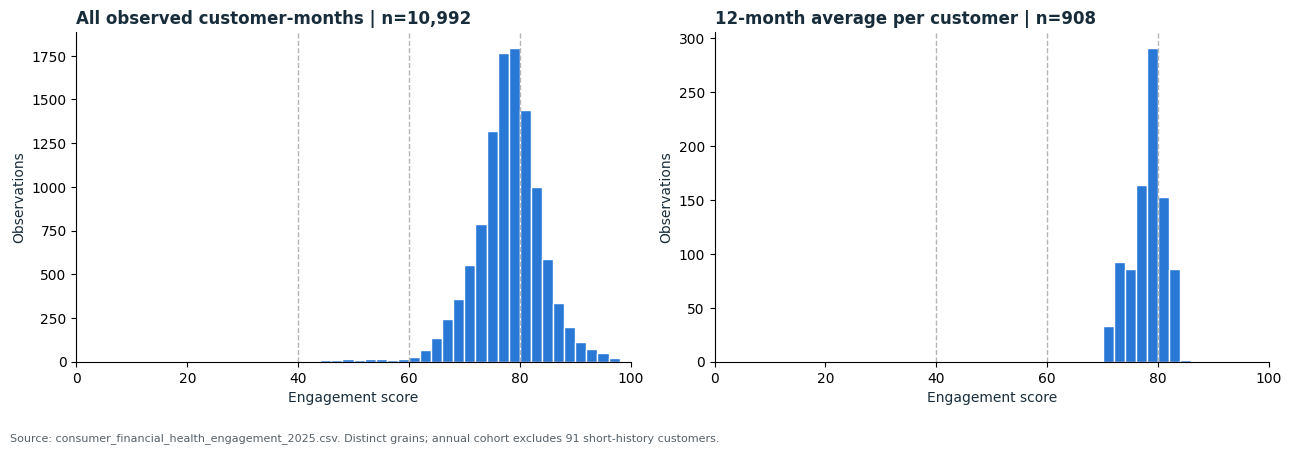

### Điểm cao là phổ biến, không phải bằng chứng mọi khách đều gắn bó sâu
**99.00% khách hàng-tháng** thuộc nhóm cao/rất cao. Điểm tháng trung vị **78.1**, khoảng **9.7–99.6**.
Với 908 khách đủ năm, điểm trung bình mỗi khách chỉ trải từ **69.79 đến 84.32**, không ai dưới 60.
Như vậy, nhãn “cao” có ít khả năng phân biệt trong dữ liệu này. Cần nhìn thêm **độ sâu sử dụng kênh** và phân bố hành vi, không tự nâng ngưỡng rồi gọi khách là mất tương tác.

In [3]:
BANDS = ['Low <40', 'Moderate 40-<60', 'High 60-<80', 'Very high >=80']
def bands(values: pd.Series) -> pd.Series:
    return pd.Series(pd.cut(values, [-np.inf,40,60,80,np.inf], right=False, labels=BANDS))
label_map = {'Tương tác thấp':BANDS[0], 'Tương tác trung bình':BANDS[1],
             'Tương tác cao':BANDS[2], 'Tương tác rất cao':BANDS[3]}
assert bands(cm.engagement_score).astype(str).eq(cm.engagement_segment.map(label_map)).all()
scopes = {'All observed months (10992)': cm.engagement_score,
          'Full-year customers (908)': full.engagement,
          'All customers, observed-month mean (999)': annual.engagement,
          'December observed customers (918)': dec.engagement_score}
segment_table = pd.DataFrame(index=BANDS)
for label, values in scopes.items():
    counts = bands(values).value_counts().reindex(BANDS, fill_value=0)
    segment_table[label+' n'] = counts
    segment_table[label+' %'] = counts / len(values) * 100
table('05_engagement_segments', segment_table)
table('06_engagement_distribution', pd.DataFrame({k:v.describe() for k,v in scopes.items()}))
fig, axs = plt.subplots(1, 2, figsize=(13,4.5))
for ax, values, title in [(axs[0],cm.engagement_score,'All observed customer-months | n=10,992'),
                         (axs[1],full.engagement,'12-month average per customer | n=908')]:
    ax.hist(values, bins=np.arange(0,102,2), color=BLUE, edgecolor='white')
    for cut in [40,60,80]: ax.axvline(cut, color=GRAY, linestyle='--', linewidth=1)
    ax.set(title=title, xlabel='Engagement score', ylabel='Observations', xlim=(0,100))
save(fig,'01_distribution','Source: consumer_financial_health_engagement_2025.csv. Distinct grains; annual cohort excludes 91 short-history customers.')
high_share = cm.engagement_score.ge(60).mean()
say(f'''### Điểm cao là phổ biến, không phải bằng chứng mọi khách đều gắn bó sâu
**{high_share:.2%} khách hàng-tháng** thuộc nhóm cao/rất cao. Điểm tháng trung vị **{cm.engagement_score.median():.1f}**, khoảng **{cm.engagement_score.min():.1f}–{cm.engagement_score.max():.1f}**.
Với 908 khách đủ năm, điểm trung bình mỗi khách chỉ trải từ **{full.engagement.min():.2f} đến {full.engagement.max():.2f}**, không ai dưới 60.
Như vậy, nhãn “cao” có ít khả năng phân biệt trong dữ liệu này. Cần nhìn thêm **độ sâu sử dụng kênh** và phân bố hành vi, không tự nâng ngưỡng rồi gọi khách là mất tương tác.''')

## 3. Adoption không đồng nghĩa với tỷ trọng sử dụng
Ba câu hỏi khác nhau: **đã dùng chưa** (khách duy nhất), **dùng bao nhiêu lần** (giao dịch), **bao nhiêu tiền đi qua kênh** (chi tiêu).
Adoption = số khách có ít nhất 1 giao dịch qua kênh trong năm / 999. Một khách dùng nhiều kênh nên tổng adoption có thể vượt 100%.
**Online** theo cờ dữ liệu. **Digital mở rộng** được định nghĩa ở đây là mọi kênh không phải POS, bao gồm QR; đây là định nghĩa phân tích, không sửa cờ gốc.

online_transaction_flag,0,1
transaction_channel,,
POS,1089518,0
QR Payment,367682,0
E-commerce,0,161670
Mobile App,0,142399
Recurring Payment,0,91125


,transactions,users,spend_vnd,adoption_pct,transaction_pct,spend_pct
transaction_channel,,,,,,
POS,1089518,999,1899348287000,100.0000,58.8168,58.5382
QR Payment,367682,975,636765582000,97.5976,19.8490,19.6252
E-commerce,161670,989,312147896000,98.9990,8.7276,9.6204
Mobile App,142399,980,246823404000,98.0981,7.6873,7.6071
Recurring Payment,91125,942,149547789000,94.2943,4.9193,4.6091


,ratio
Mean online ratio across 10992 observed customer-months,0.2103
"Equal-customer mean of observed-month online ratios, 999 customers",0.2471
"Equal-customer mean of annual online/spend ratios, 999 customers",0.2565
"Mean monthly online ratio, 908 complete customers x 12",0.2064
"Pooled online spend / total spend, all transactions",0.2184
"Pooled non-POS digital spend / total spend, all transactions",0.4146
Non-POS transaction count / all transactions,0.4118


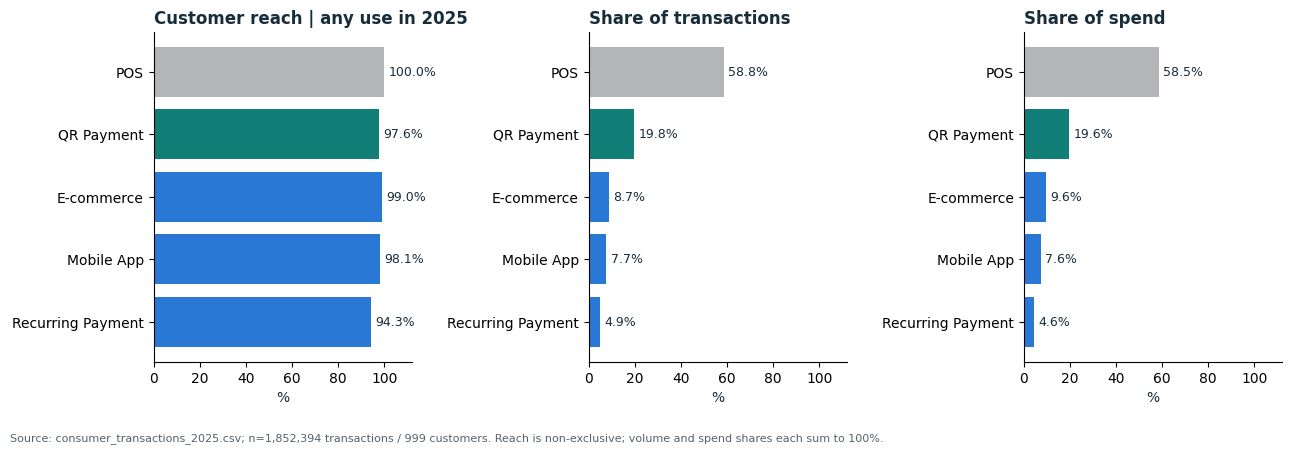

transaction_channel,POS,QR Payment,E-commerce,Mobile App,Recurring Payment
analysis_month,,,,,
2025-01-01,100.0000,99.5633,98.4716,98.2533,93.5590
2025-02-01,100.0000,99.7824,98.8030,98.1502,95.3210
2025-03-01,100.0000,99.6739,99.6739,98.9130,97.3913
2025-04-01,99.8912,99.5647,99.2383,98.9119,97.0620
2025-05-01,100.0000,99.8909,99.3457,99.1276,98.1461
2025-06-01,100.0000,99.8902,99.5609,99.8902,98.6828
2025-07-01,100.0000,99.8905,99.5619,99.6714,98.7952
2025-08-01,100.0000,100.0000,99.6707,99.7805,98.6828
2025-09-01,100.0000,99.5647,99.6736,99.1295,97.4973


### Khoảng trống nằm ở mức sử dụng, không chỉ ở lần dùng đầu tiên
- POS đã được **999/999** khách dùng; ngay cả kênh có ít người dùng nhất cũng đạt **94.29%** trong năm.
- Tuy vậy POS chiếm **58.82% giao dịch** và **58.54% chi tiêu**. “Từng dùng app” không có nghĩa app là kênh chủ đạo, càng không chứng minh khách sẽ đọc thông báo.
- **Trung bình tỷ trọng online theo khách hàng-tháng = 21.03%**; lấy tỷ lệ tổng tiền online / tổng tiền toàn danh mục = **21.84%**. Hai đại lượng khác trọng số, không thay thế cho nhau.
- **QR có toàn bộ giao dịch mang cờ online=0**. Digital mở rộng chiếm **41.46% chi tiêu**, cao hơn online do cộng QR. Phần chênh là **19.63 điểm phần trăm**, không phải lỗi tổng hợp.
- Bảng adoption theo tháng giúp tránh nhầm việc đã dùng một lần trong cả năm với thói quen lặp lại.

In [4]:
CHANNELS = ['POS','QR Payment','E-commerce','Mobile App','Recurring Payment']
cross = pd.crosstab(tx.transaction_channel, tx.online_transaction_flag).reindex(CHANNELS)
table('07_channel_online_flag', cross)
channel = pd.DataFrame(tx.groupby('transaction_channel', observed=True).agg(
    transactions=('transaction_id','size'), users=('consumer_id','nunique'), spend_vnd=('spend_amount_vnd','sum'))).reindex(CHANNELS)
channel['adoption_pct'] = channel.users / len(annual) * 100
channel['transaction_pct'] = channel.transactions / len(tx) * 100
channel['spend_pct'] = channel.spend_vnd / tx.spend_amount_vnd.sum() * 100
table('08_channel_adoption', channel)
shares = pd.Series({
    'Mean online ratio across 10992 observed customer-months':cm.online_spend_ratio.mean(),
    'Equal-customer mean of observed-month online ratios, 999 customers':annual.online_month_mean.mean(),
    'Equal-customer mean of annual online/spend ratios, 999 customers':annual.online_year_share.mean(),
    'Mean monthly online ratio, 908 complete customers x 12':full.online_month_mean.mean(),
    'Pooled online spend / total spend, all transactions':tx.online_vnd.sum()/tx.spend_amount_vnd.sum(),
    'Pooled non-POS digital spend / total spend, all transactions':tx.digital_vnd.sum()/tx.spend_amount_vnd.sum(),
    'Non-POS transaction count / all transactions':tx.transaction_channel.ne('POS').mean(),
}, name='ratio')
table('09_online_digital_definitions', shares.to_frame())
fig, axs = plt.subplots(1,3,figsize=(13,4.5))
for ax,col,title in zip(axs,['adoption_pct','transaction_pct','spend_pct'],
                      ['Customer reach | any use in 2025','Share of transactions','Share of spend']):
    bars=ax.barh(CHANNELS,channel[col],color=[GRAY,TEAL,BLUE,BLUE,BLUE])
    ax.bar_label(bars,labels=[f'{x:.1f}%' for x in channel[col]],padding=3,fontsize=9)
    ax.set(title=title,xlim=(0,112),xlabel='%'); ax.invert_yaxis()
save(fig,'02_channels','Source: consumer_transactions_2025.csv; n=1,852,394 transactions / 999 customers. Reach is non-exclusive; volume and spend shares each sum to 100%.')
monthly_channel = tx.groupby(['analysis_month','transaction_channel'],observed=True).consumer_id.nunique().unstack().reindex(columns=CHANNELS)
monthly_channel = monthly_channel.div(cm.groupby('analysis_month').consumer_id.nunique(),axis=0)*100
table('10_monthly_channel_reach_pct',monthly_channel)
say(f'''### Khoảng trống nằm ở mức sử dụng, không chỉ ở lần dùng đầu tiên
- POS đã được **{int(channel.loc['POS','users'])}/999** khách dùng; ngay cả kênh có ít người dùng nhất cũng đạt **{channel.adoption_pct.min():.2f}%** trong năm.
- Tuy vậy POS chiếm **{channel.loc['POS','transaction_pct']:.2f}% giao dịch** và **{channel.loc['POS','spend_pct']:.2f}% chi tiêu**. “Từng dùng app” không có nghĩa app là kênh chủ đạo, càng không chứng minh khách sẽ đọc thông báo.
- **Trung bình tỷ trọng online theo khách hàng-tháng = {cm.online_spend_ratio.mean():.2%}**; lấy tỷ lệ tổng tiền online / tổng tiền toàn danh mục = **{shares.iloc[4]:.2%}**. Hai đại lượng khác trọng số, không thay thế cho nhau.
- **QR có toàn bộ giao dịch mang cờ online=0**. Digital mở rộng chiếm **{shares.iloc[5]:.2%} chi tiêu**, cao hơn online do cộng QR. Phần chênh là **{channel.loc['QR Payment','spend_pct']:.2f} điểm phần trăm**, không phải lỗi tổng hợp.
- Bảng adoption theo tháng giúp tránh nhầm việc đã dùng một lần trong cả năm với thói quen lặp lại.''')

## 4. Độ rộng và nhịp giao dịch: nhìn cả phân bố lẫn liên hệ
Diversity đếm số nhóm chi tiêu khác nhau **trong một tháng**, không đo độ cân bằng phân bổ tiền.
Frequency là số giao dịch/tháng; active days là số ngày giao dịch; bổ sung frequency/ngày lịch để giảm khác biệt độ dài tháng.
Recency=0 nghĩa là giao dịch vào ngày cuối tháng, không phải không giao dịch. Đây không phải số ngày tính đến hôm nay.
Dùng Spearman cho quan hệ thứ hạng, báo riêng toàn mẫu và mẫu đủ năm. Không gắn p-value độc lập cho các tháng lặp lại cùng khách.

,count,mean,std,min,25%,50%,75%,max
category_diversity,"10,992.0000",13.6617,1.0118,2.0000,14.0000,14.0000,14.0000,14.0000
transaction_count,"10,992.0000",168.5220,106.3900,2.0000,83.0000,150.0000,223.0000,713.0000
active_transaction_days,"10,992.0000",28.6313,3.6887,1.0000,28.0000,30.0000,31.0000,31.0000
transaction_recency_days,"10,992.0000",0.1661,1.5456,0.0000,0.0000,0.0000,0.0000,30.0000
transactions_per_calendar_day,"10,992.0000",5.5248,3.4490,0.0645,2.7742,4.9355,7.3000,23.0000


,count,mean,std,min,25%,50%,75%,max
category_diversity,"10,896.0000",13.7393,0.5760,9.0000,14.0000,14.0000,14.0000,14.0000
transaction_count,"10,896.0000",169.9238,105.7993,25.0000,86.0000,151.0000,223.0000,713.0000
active_transaction_days,"10,896.0000",28.8670,2.7132,15.0000,28.0000,30.0000,31.0000,31.0000
transaction_recency_days,"10,896.0000",0.0508,0.2574,0.0000,0.0000,0.0000,0.0000,4.0000
transactions_per_calendar_day,"10,896.0000",5.5708,3.4291,0.8387,2.8929,5.0000,7.3253,23.0000


,All observed customer-months,Full-panel customer-months
category_diversity,0.4325,0.4119
transaction_count,0.4992,0.4859
active_transaction_days,0.4226,0.4067
transaction_recency_days,-0.2163,-0.1701
transactions_per_calendar_day,0.4989,0.4856
online_spend_ratio,0.8257,0.8703


,Spearman across 908 customers
frequency,0.7880
diversity,0.7929
active_days,0.7683
recency,-0.5858
online_month_mean,0.6114


,n,median_score
category_diversity,,
2,3,12.8000
3,9,45.3000
4,19,50.9000
5,40,48.8500
6,18,51.6000
7,7,51.1000
9,1,61.9000
10,19,63.2000
11,82,68.0500


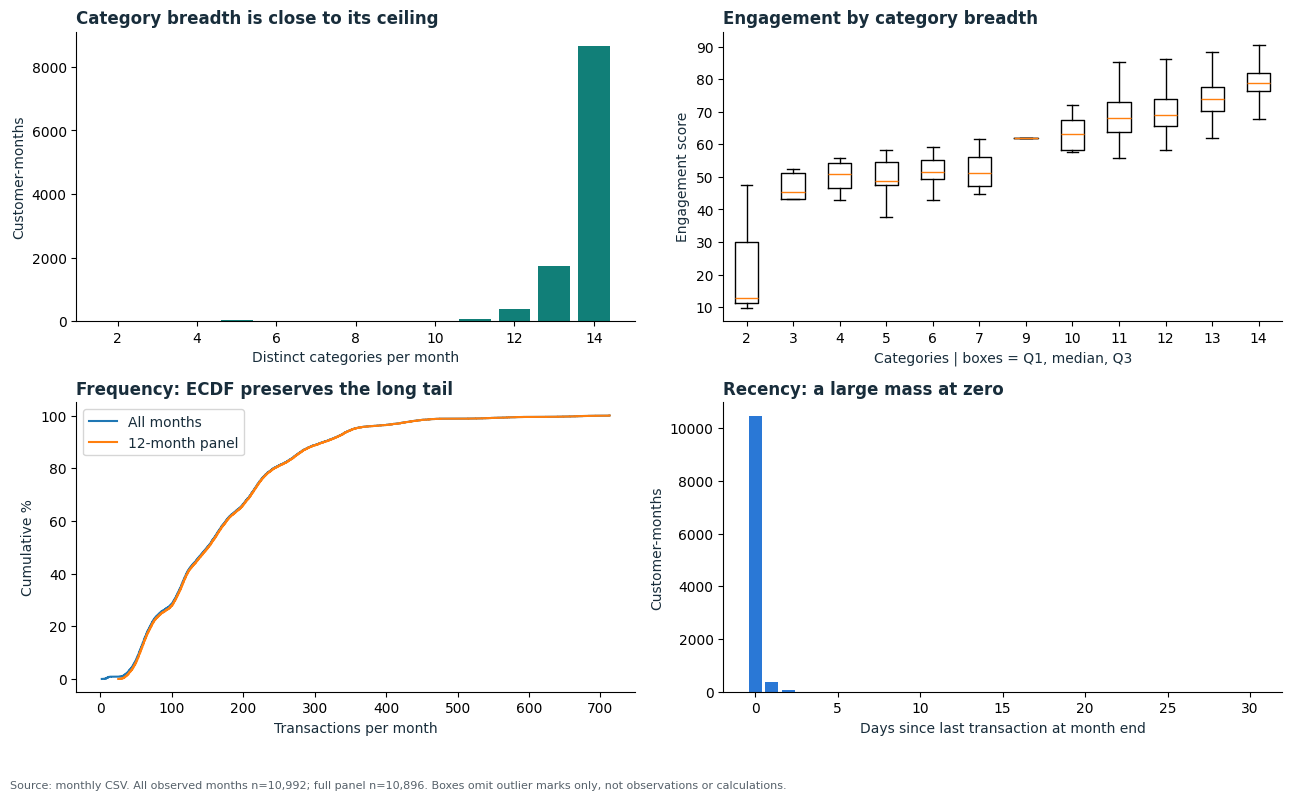

,n,median_score
freq_band,,
<50,764,68.6000
50-99,2353,74.1000
100-199,4166,78.1000
200-399,3319,80.0000
400+,390,80.6000


,n,median_score
rec_band,,
0,10435,78.3000
1,399,72.5000
2-3,82,69.7500
4-7,17,53.9000
8-30,59,48.0000


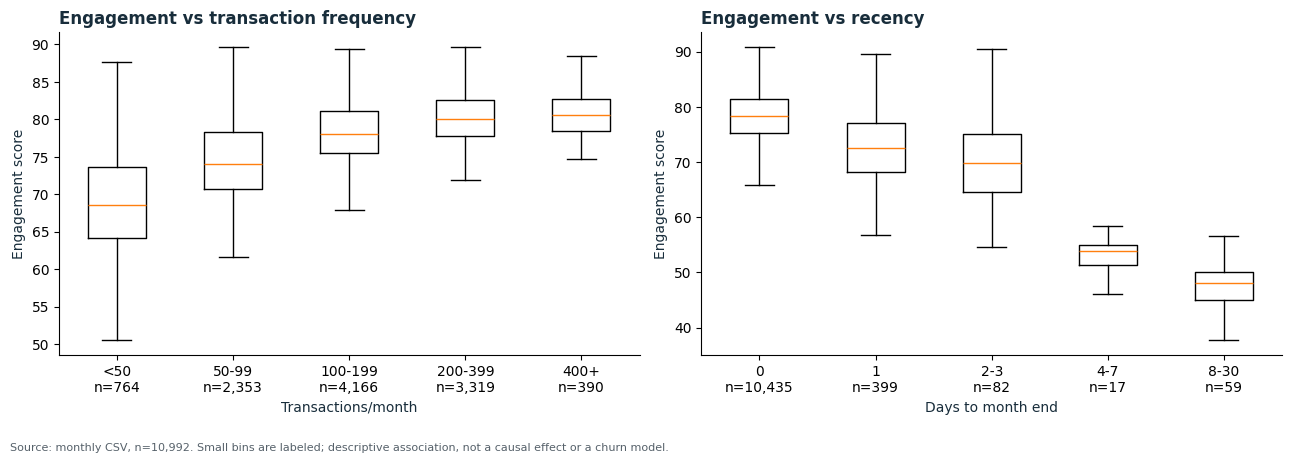

### Hai chỉ số bị nén ở trần/sàn
**78.85% khách hàng-tháng đạt đủ 14 nhóm chi tiêu**, và **94.93% có recency=0**. Vì vậy chỉ nhìn trung vị dễ bỏ qua đuôi nhỏ có hành vi khác biệt.
Frequency có khoảng **2–713**, trung vị **150 giao dịch/tháng**, IQR **83–223**; active days **1–31**, trung vị **30**.
Recency **0–30 ngày**; diversity **2–14 nhóm**.

Spearman toàn mẫu với engagement: diversity **0.432**, frequency **0.499**, recency **-0.216**, online share **0.826**.
Các hệ số này mô tả mức đi cùng nhau, **không chứng minh** tăng số giao dịch, thêm nhóm mua sắm hay chuyển online sẽ làm khách trung thành hơn. Không khuyến khích khách mua thêm chỉ để tăng điểm.

In [5]:
cm['transactions_per_calendar_day'] = cm.transaction_count / cm.analysis_month.dt.days_in_month
METRICS = ['category_diversity','transaction_count','active_transaction_days','transaction_recency_days','transactions_per_calendar_day']
table('11_behavior_ranges',cm[METRICS].describe(percentiles=[.25,.5,.75]).T)
table('12_behavior_ranges_full_panel',pd.DataFrame(cm.loc[cm.observed_months.eq(12),METRICS]).describe().T)
association = pd.DataFrame({
    'All observed customer-months':cm[METRICS+['online_spend_ratio']].corrwith(cm.engagement_score,method='spearman'),
    'Full-panel customer-months':pd.DataFrame(cm.loc[cm.observed_months.eq(12),METRICS+['online_spend_ratio']]).corrwith(cm.loc[cm.observed_months.eq(12),'engagement_score'],method='spearman')})
table('13_spearman_associations',association)
table('14_customer_level_associations',full[['frequency','diversity','active_days','recency','online_month_mean']].corrwith(full.engagement,method='spearman').rename('Spearman across 908 customers').to_frame())
diversity = cm.groupby('category_diversity').agg(n=('consumer_id','size'),median_score=('engagement_score','median'))
table('15_category_diversity',diversity)
fig,axs=plt.subplots(2,2,figsize=(13,8))
axs[0,0].bar(diversity.index,diversity.n,color=TEAL)
axs[0,0].set(title='Category breadth is close to its ceiling',xlabel='Distinct categories per month',ylabel='Customer-months',xticks=range(2,15,2))
groups=[cm.loc[cm.category_diversity.eq(k),'engagement_score'] for k in diversity.index]
axs[0,1].boxplot(groups,tick_labels=diversity.index,showfliers=False)
axs[0,1].set(title='Engagement by category breadth',xlabel='Categories | boxes = Q1, median, Q3',ylabel='Engagement score')
for label,g in [('All months',cm),('12-month panel',cm[cm.observed_months.eq(12)])]:
    x=np.sort(g.transaction_count)
    axs[1,0].step(x,np.arange(1,len(x)+1)/len(x)*100,where='post',label=label)
axs[1,0].set(title='Frequency: ECDF preserves the long tail',xlabel='Transactions per month',ylabel='Cumulative %');axs[1,0].legend()
rec=cm.transaction_recency_days.value_counts().sort_index()
axs[1,1].bar(rec.index,rec.values,color=BLUE)
axs[1,1].set(title='Recency: a large mass at zero',xlabel='Days since last transaction at month end',ylabel='Customer-months')
save(fig,'03_behavior_ranges','Source: monthly CSV. All observed months n=10,992; full panel n=10,896. Boxes omit outlier marks only, not observations or calculations.')
cm['freq_band']=pd.cut(cm.transaction_count,[0,50,100,200,400,np.inf],right=False,
    labels=['<50','50-99','100-199','200-399','400+'])
cm['rec_band']=pd.cut(cm.transaction_recency_days,[-1,0,1,3,7,31],labels=['0','1','2-3','4-7','8-30'])
fig,axs=plt.subplots(1,2,figsize=(13,4.6))
for ax,col,title in [(axs[0],'freq_band','Engagement vs transaction frequency'),(axs[1],'rec_band','Engagement vs recency')]:
    group=cm.groupby(col,observed=True)
    ax.boxplot([g.engagement_score for _,g in group],tick_labels=[f'{k}\nn={len(g):,}' for k,g in group],showfliers=False)
    ax.set(title=title,ylabel='Engagement score',xlabel='Transactions/month' if col=='freq_band' else 'Days to month end')
    table('16_'+col+'_profile',group.agg(n=('consumer_id','size'),median_score=('engagement_score','median')))
save(fig,'04_behavior_links','Source: monthly CSV, n=10,992. Small bins are labeled; descriptive association, not a causal effect or a churn model.')
cap=cm.category_diversity.eq(14).mean();zero=cm.transaction_recency_days.eq(0).mean()
say(f'''### Hai chỉ số bị nén ở trần/sàn
**{cap:.2%} khách hàng-tháng đạt đủ 14 nhóm chi tiêu**, và **{zero:.2%} có recency=0**. Vì vậy chỉ nhìn trung vị dễ bỏ qua đuôi nhỏ có hành vi khác biệt.
Frequency có khoảng **{cm.transaction_count.min()}–{cm.transaction_count.max()}**, trung vị **{cm.transaction_count.median():.0f} giao dịch/tháng**, IQR **{cm.transaction_count.quantile(.25):.0f}–{cm.transaction_count.quantile(.75):.0f}**; active days **{cm.active_transaction_days.min()}–{cm.active_transaction_days.max()}**, trung vị **{cm.active_transaction_days.median():.0f}**.
Recency **{cm.transaction_recency_days.min()}–{cm.transaction_recency_days.max()} ngày**; diversity **{cm.category_diversity.min()}–{cm.category_diversity.max()} nhóm**.

Spearman toàn mẫu với engagement: diversity **{association.loc['category_diversity'].iloc[0]:.3f}**, frequency **{association.loc['transaction_count'].iloc[0]:.3f}**, recency **{association.loc['transaction_recency_days'].iloc[0]:.3f}**, online share **{association.loc['online_spend_ratio'].iloc[0]:.3f}**.
Các hệ số này mô tả mức đi cùng nhau, **không chứng minh** tăng số giao dịch, thêm nhóm mua sắm hay chuyển online sẽ làm khách trung thành hơn. Không khuyến khích khách mua thêm chỉ để tăng điểm.''')

## 5. High-health / low-engagement: trả lời đúng trước, mở rộng sau
**Nhóm tuyệt đối:** health ≥80 và engagement <40 ở **cùng tháng**. Health 80 nhất quán với Task 1 của đề; engagement 40 khớp nhóm “Tương tác thấp” gốc, dễ giải thích và không tùy chỉnh để tạo nhóm lớn.
So với ngưỡng chặt hơn E<30 và lỏng hơn E<60, ngưỡng 40 giữ đúng nghĩa “low”; 60 gộp cả “moderate” nên chỉ gọi nhóm theo dõi mở rộng. Kiểm tra thêm health 75/80/85.
**Nhóm bổ sung nhất quán Task 2:** với 908 khách đủ năm, health trung bình ≥Q75 và engagement trung bình ≤Q25; gọi chính xác **“tương đối khỏe hơn nhưng tương tác thấp hơn”**. Không được gọi 76 điểm là mất tương tác tuyệt đối.

,health_min,engagement_max_exclusive,customer_months,unique_customers,pct_of_999_customers,annual_full_panel_customers
0,75,30,2,2,0.2002,0
1,75,40,2,2,0.2002,0
2,75,60,25,25,2.5025,0
3,80,30,1,1,0.1001,0
4,80,40,1,1,0.1001,0
5,80,60,6,6,0.6006,0
6,85,30,1,1,0.1001,0
7,85,40,1,1,0.1001,0
8,85,60,4,4,0.4004,0


,analysis_month,observed_months,age,gender,occupation,province_city,financial_health_score,engagement_score,transaction_count,active_transaction_days,category_diversity,transaction_recency_days,online_spend_ratio,spend_to_income_ratio
consumer_id,,,,,,,,,,,,,,
KH00114725,2025-02-01,2,50,Nam,Chuyên viên di truyền tế bào lâm sàng,Thành phố Hồ Chí Minh,88.3000,12.3000,3,1,3,27,0.0000,0.1187


,analysis_month,observed_months,age,gender,occupation,province_city,financial_health_score,engagement_score,transaction_count,active_transaction_days,category_diversity,transaction_recency_days,online_spend_ratio,spend_to_income_ratio
consumer_id,,,,,,,,,,,,,,
KH00105725,2025-01-01,12,53,Nam,Luật sư sáng chế,Nghệ An,86.3000,57.5000,35,18,11,0,0.0171,0.1995
KH00107005,2025-01-01,12,53,Nam,Kỹ sư vật liệu,Tuyên Quang,85.4000,59.8000,34,16,12,2,0.0754,0.2309
KH00108245,2025-01-01,12,50,Nam,Chuyên viên biên tập nội dung,Thành phố Hồ Chí Minh,84.5000,59.9000,32,19,10,2,0.1191,0.3005
KH00112770,2025-02-01,12,75,Nữ,Nhà địa chất thủy văn,Đồng Nai,82.0000,58.4000,30,17,12,0,0.0095,0.3388
KH00114725,2025-02-01,2,50,Nam,Chuyên viên di truyền tế bào lâm sàng,Thành phố Hồ Chí Minh,88.3000,12.3000,3,1,3,27,0.0000,0.1187
KH00119485,2025-02-01,12,52,Nam,Bác sĩ đo mắt,Đồng Tháp,86.2000,58.6000,29,20,10,0,0.0511,0.2180


,tail_fraction,health_min_inclusive,engagement_max_inclusive,customers,pct_of_908
0,0.1000,71.9608,73.3725,13,1.4317
1,0.2500,69.1583,76.2500,59,6.4978
2,0.3300,68.3307,77.3083,99,10.9031


,Target n=59,Other n=849
health,71.6750,66.0083
engagement,73.9250,78.7333
age,55.0000,47.0000
frequency,61.5833,182.6667
active_days,25.4167,30.0833
diversity,13.2500,13.9167
recency,0.0833,0.0000
online_month_mean,0.1855,0.2012
online_year_share,0.1955,0.2113
spend_income,0.5457,0.7127


,target_n,full_panel_n,target_pct,full_panel_pct
gender,,,,
Nam,34,448,57.6271,49.3392
Nữ,25,460,42.3729,50.6608


,target_n,full_panel_n,target_pct,full_panel_pct
occupation,,,,
Kỹ sư vật liệu,3.0000,7,5.0847,0.7709
Kỹ sư khai thác mỏ,2.0000,6,3.3898,0.6608
Giám đốc tiếp thị,2.0000,2,3.3898,0.2203
Quản lý sân khấu,1.0000,1,1.6949,0.1101
Bác sĩ đo mắt,1.0000,2,1.6949,0.2203
...,...,...,...,...
Bác sĩ giải phẫu bệnh,0.0000,1,0.0000,0.1101
Bác sĩ chuyên khoa bàn chân,0.0000,4,0.0000,0.4405
Bác sĩ bệnh viện,0.0000,3,0.0000,0.3304


,target_n,full_panel_n,target_pct,full_panel_pct
province,,,,
Thành phố Hồ Chí Minh,9.0000,121,15.2542,13.3260
Cần Thơ,8.0000,41,13.5593,4.5154
Đồng Tháp,5.0000,33,8.4746,3.6344
Hà Nội,5.0000,72,8.4746,7.9295
Hưng Yên,4.0000,34,6.7797,3.7445
Đắk Lắk,3.0000,23,5.0847,2.5330
Ninh Bình,3.0000,26,5.0847,2.8634
Hải Phòng,3.0000,32,5.0847,3.5242
Tuyên Quang,2.0000,16,3.3898,1.7621


,observed_months,age,gender,occupation,province,health,engagement,...,online_month_mean,online_vnd,total_vnd,spend_income,essential_share,online_year_share,relative_target
consumer_id,,,,,,,,,,,,,,,
KH00100405,12,20,Nam,Kế toán công chứng,Thành phố Hồ Chí Minh,70.2667,76.0833,...,0.2528,443332000,1414501000,0.6476,0.2954,0.3134,True
KH00101250,12,48,Nữ,Giám đốc tiếp thị,Khánh Hòa,77.2167,75.5000,...,0.1545,302337000,1980410000,0.3527,0.5534,0.1527,True
KH00101285,12,69,Nam,Giám đốc vận hành,Thành phố Hồ Chí Minh,80.8250,71.8000,...,0.1634,191770000,1118100000,0.3009,0.5843,0.1715,True
KH00101290,12,47,Nam,Nhà giao dịch hợp đồng tương lai,Thành phố Hồ Chí Minh,72.8083,74.9583,...,0.2148,437579000,1890322000,0.5004,0.3771,0.2315,True
KH00101445,12,33,Nữ,Chuyên viên ngân hàng đầu tư vận hành,Nghệ An,74.4167,70.3500,...,0.1221,120899000,1023033000,0.4920,0.5995,0.1182,True
KH00101450,12,57,Nữ,Kỹ sư đóng tàu,Cần Thơ,70.8583,71.2333,...,0.1686,209360000,1201895000,0.5865,0.5292,0.1742,True
KH00102725,12,44,Nam,Quản lý tour du lịch,Hà Nội,70.2583,75.9583,...,0.2360,291843000,1088124000,0.6135,0.5521,0.2682,True
KH00103725,12,55,Nam,Chuyên viên tư vấn làm vườn,Thành phố Hồ Chí Minh,69.7917,72.8333,...,0.1895,314495000,1247914000,0.6303,0.4863,0.2520,True
KH00104410,12,59,Nữ,Dược sĩ bệnh viện,Hưng Yên,70.7917,74.7250,...,0.2349,408457000,1449695000,0.5486,0.4354,0.2818,True


,observed_months,age,gender,occupation,province,health,engagement,...,recency,online_month_mean,online_vnd,total_vnd,spend_income,essential_share,online_year_share
consumer_id,,,,,,,,,,,,,,,
KH00100010,12,27,Nam,Kỹ sư sản xuất,Đồng Nai,70.6167,78.2917,...,0.0000,0.1673,1180351000,7036618000,0.5916,0.3811,0.1677
KH00100045,12,62,Nữ,Chuyên viên sinh lý vận động,Nghệ An,68.4833,77.4250,...,0.1667,0.1916,507563000,2539338000,0.6246,0.4769,0.1999
KH00100050,12,81,Nữ,Nhà thiết kế dệt may,Cần Thơ,60.9583,78.7000,...,0.0000,0.2162,512784000,2390488000,0.7925,0.5049,0.2145
KH00100085,12,32,Nữ,Nhà địa vật lý,Thành phố Hồ Chí Minh,67.5167,80.4417,...,0.0000,0.2200,1053955000,4693772000,0.6587,0.4507,0.2245
KH00100090,2,18,Nam,Kỹ sư hóa học,Tuyên Quang,67.8500,49.2500,...,15.0000,0.8609,165813000,199844000,0.5192,0.0012,0.8297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KH00119890,12,48,Nữ,Nghiên cứu viên lâm sàng,Đồng Tháp,63.1000,80.0667,...,0.0000,0.3191,527785000,1671595000,0.7818,0.4521,0.3157
KH00119925,12,27,Nữ,Nhà văn,Nghệ An,67.1000,75.5000,...,0.1667,0.2487,393997000,1671186000,0.6974,0.4772,0.2358
KH00119930,1,72,Nam,Kiểm soát viên không lưu,Thành phố Hồ Chí Minh,61.7000,52.0000,...,11.0000,0.9510,147349000,154949000,0.6666,0.0490,0.9510


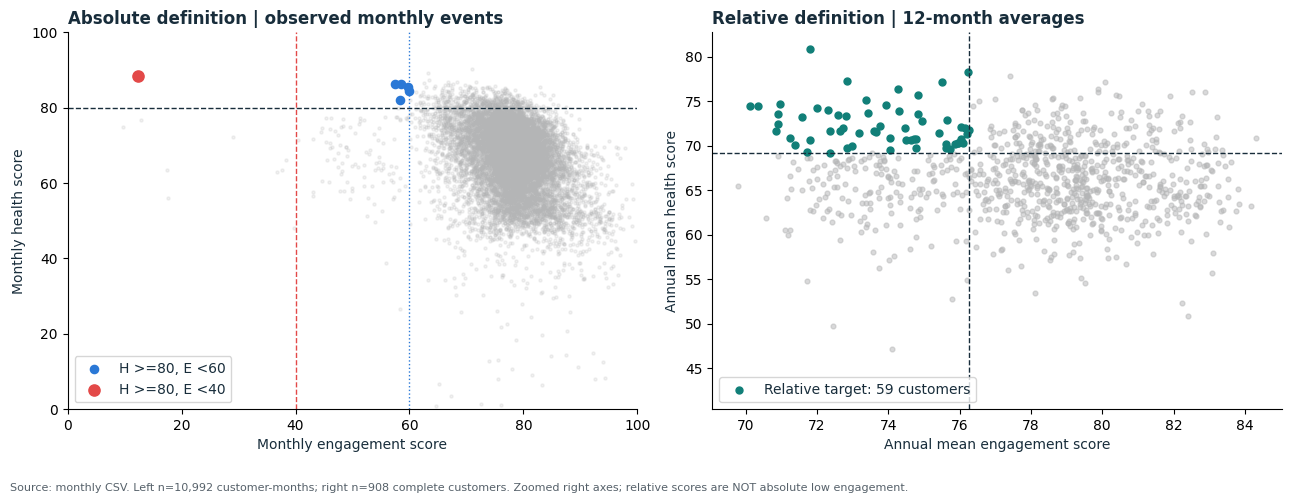

### Trả lời trực tiếp yêu cầu nhận diện nhóm
**Ngưỡng tuyệt đối H≥80 và E<40:** 1 khách hàng-tháng, **1/999 khách (0.10%)**, chiếm 0.0091% số dòng tháng.
Đó là **KH00114725, tháng 02/2025**, health 88,3; engagement 12,3; **3 giao dịch trong 1 ngày, 3 nhóm chi tiêu, recency 27 ngày, tỷ trọng online 0%**, chi/thu nhập 0,1187. Hồ sơ ghi nam, 50 tuổi, nghề di truyền tế bào lâm sàng, TP.HCM. Đây là mô tả một trường hợp, **không suy rộng cho giới/tuổi/nghề/tỉnh**.

Nới E<60 có **6 tháng / 6 khách**, nhưng năm trường hợp bổ sung thuộc nhóm *tương tác trung bình*. Chọn 40 vì khớp nhãn gốc; ngưỡng 30 không tạo khác biệt về quy mô ở mẫu này. Không có cơ sở để tuyên bố 30 hoặc 40 là ngưỡng churn tối ưu.
Trên **trung bình đủ 12 tháng**, nhóm H≥80 và E<40 có **0/908 khách**. Đây là kết quả cần báo cáo, không phải lý do sửa tên nhóm.

### Mở rộng có kiểm soát: cơ hội nuôi dưỡng, không phải danh sách “sắp rời bỏ”
Chọn **health trung bình ≥ 69.15833333** và **engagement trung bình ≤ 76.25000000** (tính bằng giá trị chưa làm tròn): **59/908 khách = 6.50%**; tương đương 5.91% trong 999 khách toàn bộ, nhưng 91 khách ít lịch sử không đủ điều kiện đánh giá theo quy tắc này.
Hai mốc 25% đối xứng cách làm Task 2 và có khả năng tập trung nguồn lực; không phải ngưỡng tối ưu đã được kiểm chứng. Tail 10% chọn **13** khách, tập trung hơn nhưng phủ hẹp; 33% chọn **99** khách, phủ rộng hơn nhưng giảm tính chọn lọc. Chọn 25% như **quy tắc thiết kế minh bạch** cho thử nghiệm, không giả vờ có bằng chứng hiệu quả.

Khách điển hình của nhóm tương đối có **61.6 giao dịch/tháng** so với **182.7** ở phần còn lại; tỷ trọng online bình quân tháng **18.55%** so với **20.12%**; chi/thu nhập **0.546** so với **0.713**. Đây là trung vị của các chỉ số mỗi khách, không phải trung vị mọi giao dịch.
Chênh lệch điểm health/engagement vốn được tạo bởi điều kiện chọn nhóm; chỉ các chỉ số hành vi bổ sung mới giúp hiểu chân dung.

In [6]:
literal_mask=cm.financial_health_score.ge(80)&cm.engagement_score.lt(40)
expanded_mask=cm.financial_health_score.ge(80)&cm.engagement_score.lt(60)
absolute_rows=[]
for h in [75,80,85]:
    for e in [30,40,60]:
        mask=cm.financial_health_score.ge(h)&cm.engagement_score.lt(e)
        absolute_rows.append({'health_min':h,'engagement_max_exclusive':e,
            'customer_months':int(mask.sum()),'unique_customers':cm.loc[mask,'consumer_id'].nunique(),
            'pct_of_999_customers':cm.loc[mask,'consumer_id'].nunique()/len(annual)*100,
            'annual_full_panel_customers':int((full.health.ge(h)&full.engagement.lt(e)).sum())})
table('17_absolute_cutoff_sensitivity',pd.DataFrame(absolute_rows))
literal_cols=['consumer_id','analysis_month','observed_months','age','gender','occupation','province_city',
    'financial_health_score','engagement_score','transaction_count','active_transaction_days',
    'category_diversity','transaction_recency_days','online_spend_ratio','spend_to_income_ratio']
table('18_absolute_low_engagement_customers',cm.loc[literal_mask,literal_cols].set_index('consumer_id'))
table('19_expanded_monitoring_customers',cm.loc[expanded_mask,literal_cols].set_index('consumer_id'))
hcut=float(full.health.quantile(.75));ecut=float(full.engagement.quantile(.25))
full['relative_target']=full.health.ge(hcut)&full.engagement.le(ecut)
target=pd.DataFrame(full[full.relative_target]);rest=pd.DataFrame(full[~full.relative_target])
sens=[]
for q in [.10,.25,.33]:
    h=full.health.quantile(1-q);e=full.engagement.quantile(q)
    mask=full.health.ge(h)&full.engagement.le(e)
    sens.append({'tail_fraction':q,'health_min_inclusive':h,'engagement_max_inclusive':e,
        'customers':int(mask.sum()),'pct_of_908':mask.mean()*100})
table('20_relative_cutoff_sensitivity',pd.DataFrame(sens))
profile_cols=['health','engagement','age','frequency','active_days','diversity','recency',
    'online_month_mean','online_year_share','spend_income','essential_share']
profile=pd.DataFrame({f'Target n={len(target)}':target[profile_cols].median(),
    f'Other n={len(rest)}':rest[profile_cols].median()})
table('21_relative_target_profile',profile)
for col in ['gender','occupation','province']:
    composition=pd.DataFrame({'target_n':target[col].value_counts(),'full_panel_n':full[col].value_counts()}).fillna(0)
    composition['target_pct']=composition.target_n/len(target)*100
    composition['full_panel_pct']=composition.full_panel_n/len(full)*100
    table('22_profile_'+col,composition.sort_values('target_n',ascending=False))
table('23_relative_target_customer_list',target)
table('24_customer_features_all',annual)
fig,axs=plt.subplots(1,2,figsize=(13,5))
axs[0].scatter(cm.engagement_score,cm.financial_health_score,s=5,alpha=.18,color=GRAY)
axs[0].scatter(cm.loc[expanded_mask,'engagement_score'],cm.loc[expanded_mask,'financial_health_score'],color=BLUE,s=35,label='H >=80, E <60')
axs[0].scatter(cm.loc[literal_mask,'engagement_score'],cm.loc[literal_mask,'financial_health_score'],color=RED,s=65,label='H >=80, E <40')
axs[0].axhline(80,color=INK,ls='--',lw=1);axs[0].axvline(40,color=RED,ls='--',lw=1);axs[0].axvline(60,color=BLUE,ls=':',lw=1)
axs[0].set(title='Absolute definition | observed monthly events',xlabel='Monthly engagement score',ylabel='Monthly health score',xlim=(0,100),ylim=(0,100));axs[0].legend(loc='lower left')
axs[1].scatter(rest.engagement,rest.health,s=12,color=GRAY,alpha=.5)
axs[1].scatter(target.engagement,target.health,s=25,color=TEAL,label=f'Relative target: {len(target)} customers')
axs[1].axhline(hcut,color=INK,ls='--',lw=1);axs[1].axvline(ecut,color=INK,ls='--',lw=1)
axs[1].set(title='Relative definition | 12-month averages',xlabel='Annual mean engagement score',ylabel='Annual mean health score');axs[1].legend(loc='lower left')
save(fig,'05_crossover','Source: monthly CSV. Left n=10,992 customer-months; right n=908 complete customers. Zoomed right axes; relative scores are NOT absolute low engagement.')
say(f'''### Trả lời trực tiếp yêu cầu nhận diện nhóm
**Ngưỡng tuyệt đối H≥80 và E<40:** {literal_mask.sum()} khách hàng-tháng, **{cm.loc[literal_mask,'consumer_id'].nunique()}/999 khách ({cm.loc[literal_mask,'consumer_id'].nunique()/len(annual):.2%})**, chiếm {literal_mask.mean():.4%} số dòng tháng.
Đó là **KH00114725, tháng 02/2025**, health 88,3; engagement 12,3; **3 giao dịch trong 1 ngày, 3 nhóm chi tiêu, recency 27 ngày, tỷ trọng online 0%**, chi/thu nhập 0,1187. Hồ sơ ghi nam, 50 tuổi, nghề di truyền tế bào lâm sàng, TP.HCM. Đây là mô tả một trường hợp, **không suy rộng cho giới/tuổi/nghề/tỉnh**.

Nới E<60 có **{int(expanded_mask.sum())} tháng / {cm.loc[expanded_mask,'consumer_id'].nunique()} khách**, nhưng năm trường hợp bổ sung thuộc nhóm *tương tác trung bình*. Chọn 40 vì khớp nhãn gốc; ngưỡng 30 không tạo khác biệt về quy mô ở mẫu này. Không có cơ sở để tuyên bố 30 hoặc 40 là ngưỡng churn tối ưu.
Trên **trung bình đủ 12 tháng**, nhóm H≥80 và E<40 có **0/908 khách**. Đây là kết quả cần báo cáo, không phải lý do sửa tên nhóm.

### Mở rộng có kiểm soát: cơ hội nuôi dưỡng, không phải danh sách “sắp rời bỏ”
Chọn **health trung bình ≥ {hcut:.8f}** và **engagement trung bình ≤ {ecut:.8f}** (tính bằng giá trị chưa làm tròn): **{len(target)}/{len(full)} khách = {len(target)/len(full):.2%}**; tương đương {len(target)/len(annual):.2%} trong 999 khách toàn bộ, nhưng 91 khách ít lịch sử không đủ điều kiện đánh giá theo quy tắc này.
Hai mốc 25% đối xứng cách làm Task 2 và có khả năng tập trung nguồn lực; không phải ngưỡng tối ưu đã được kiểm chứng. Tail 10% chọn **{sens[0]['customers']}** khách, tập trung hơn nhưng phủ hẹp; 33% chọn **{sens[2]['customers']}** khách, phủ rộng hơn nhưng giảm tính chọn lọc. Chọn 25% như **quy tắc thiết kế minh bạch** cho thử nghiệm, không giả vờ có bằng chứng hiệu quả.

Khách điển hình của nhóm tương đối có **{target.frequency.median():.1f} giao dịch/tháng** so với **{rest.frequency.median():.1f}** ở phần còn lại; tỷ trọng online bình quân tháng **{target.online_month_mean.median():.2%}** so với **{rest.online_month_mean.median():.2%}**; chi/thu nhập **{target.spend_income.median():.3f}** so với **{rest.spend_income.median():.3f}**. Đây là trung vị của các chỉ số mỗi khách, không phải trung vị mọi giao dịch.
Chênh lệch điểm health/engagement vốn được tạo bởi điều kiện chọn nhóm; chỉ các chỉ số hành vi bổ sung mới giúp hiểu chân dung.''')

## 6. Kiểm tra độ bền theo thời gian và khả năng sử dụng
Nhóm năm sử dụng cả năm 2025, chỉ có thể hỗ trợ lập kế hoạch **sau** năm 2025; không dùng nó để giả lập chiến dịch từ tháng 6.
Kiểm tra hai nửa năm dùng lại cohort 908 khách để so tính ổn định mô tả. Ngưỡng Q75/Q25 được tính riêng trong từng nửa; đây **không phải backtest churn**, cũng không đánh giá nhân quả.
Với khách ít lịch sử, tính ngày từ lần giao dịch cuối đến 31/12 như thông tin quan sát bổ sung; không giả định tài khoản còn mở trong toàn khoảng vắng.

In [7]:
halves={}
for name,mask in [('H1',full_cm.analysis_month.dt.month.le(6)),('H2',full_cm.analysis_month.dt.month.gt(6))]:
    g=pd.DataFrame(full_cm.loc[mask]).groupby('consumer_id').agg(h=('financial_health_score','mean'),e=('engagement_score','mean'))
    g=pd.DataFrame(g)
    halves[name]=set(g.loc[g.h.ge(g.h.quantile(.75))&g.e.le(g.e.quantile(.25))].index)
overlap=len(halves['H1']&halves['H2']);union=len(halves['H1']|halves['H2'])
table('25_half_year_stability',pd.DataFrame([{'H1_target':len(halves['H1']),'H2_target':len(halves['H2']),
    'intersection':overlap,'union':union,'jaccard':overlap/union}]))
follow=tx.groupby('consumer_id').activity_datetime.agg(['min','max'])
follow['days_since_last_at_2025_12_31']=(pd.Timestamp('2025-12-31')-follow['max'].dt.normalize()).dt.days
table('26_absolute_target_observation_window',follow.loc[cm.loc[literal_mask,'consumer_id'].unique()])
target_channels=pd.DataFrame(tx[tx.consumer_id.isin(target.index)].groupby('transaction_channel',observed=True).agg(
    users=('consumer_id','nunique'),transactions=('transaction_id','size'),spend=('spend_amount_vnd','sum'))).reindex(CHANNELS)
target_channels['reach_pct']=target_channels.users/len(target)*100
target_channels['transaction_pct']=target_channels.transactions/target_channels.transactions.sum()*100
table('27_target_channel_reach',target_channels)
say(f'''### Kiểm tra lại trước khi đề xuất
Hai nửa năm lần lượt có **{len(halves['H1'])}** và **{len(halves['H2'])}** khách ở góc phân vị tương đối; giao nhau **{overlap} khách**, Jaccard **{overlap/union:.2%}**. Vì danh sách có thể thay đổi, cần tính lại theo cửa sổ thời gian xác định và kiểm tra tình trạng thực tế trước khi liên hệ.

**Đề xuất “Đúng kênh, đúng nhu cầu”, không chạy đua tăng chi tiêu:**
1. **Xác minh trước:** 1 trường hợp H≥80/E<40 và 5 trường hợp bổ sung E<60 là tín hiệu lịch sử, không phải sáu ca churn đã xác nhận. Kiểm tra ngày mở/đóng tài khoản, độ đầy đủ dữ liệu và sự đồng ý nhận liên hệ.
2. **Pilot tự nguyện cho {len(target)} khách tương đối:** hỏi kênh mong muốn, cung cấp hướng dẫn QR/app hoặc bản tóm tắt ngân sách theo nhu cầu. Số khách đã từng dùng Mobile App là **{int(target_channels.loc['Mobile App','users'])}/{len(target)}**, nhưng không biết số người cho phép push. Không hứa reach=100% chỉ từ giao dịch app.
3. **Đo hiệu quả, không bịa kết quả:** nếu triển khai, chia ngẫu nhiên treatment/control trong nhóm đủ điều kiện sau khi xác minh consent, theo dõi 30/60 ngày. KPI: tỷ lệ khách tiếp tục hoạt động, mức hữu ích tự báo cáo, số ngày hoạt động và sử dụng kênh tự chọn; guardrail: opt-out/khiếu nại và tỷ lệ chi/thu nhập không xấu đi. Chưa có dữ liệu thử nghiệm nên **không báo uplift/ROI dự đoán**. Mẫu {len(target)} nhỏ: thí điểm khả thi trước, tính power trước thử nghiệm xác nhận.

**Giới hạn:** dữ liệu giả lập, giao dịch dày; điểm và hành vi có thể cùng xuất phát từ bộ sinh dữ liệu; không có login, consent, trạng thái tài khoản hoặc nhãn churn. Full-panel giảm khác biệt thời gian quan sát nhưng có selection/survivorship bias. Nhãn địa lý/nghề không làm căn cứ hạn chế dịch vụ. Bài này không thay thế Task 4/5, chỉ bàn giao các nhóm và giả thuyết cho hai phần đó.''')

,H1_target,H2_target,intersection,union,jaccard
0,76,68,26,118,0.2203


,min,max,days_since_last_at_2025_12_31
consumer_id,,,
KH00114725,2025-01-31 02:09:54,2025-02-01 23:54:31,333


,users,transactions,spend,reach_pct,transaction_pct
transaction_channel,,,,,
POS,59,32432,56704436000,100.0000,60.4004
QR Payment,59,11001,19782268000,100.0000,20.4879
E-commerce,59,4023,8223664000,100.0000,7.4923
Mobile App,59,3666,6613915000,100.0000,6.8275
Recurring Payment,59,2573,4246429000,100.0000,4.7919


### Kiểm tra lại trước khi đề xuất
Hai nửa năm lần lượt có **76** và **68** khách ở góc phân vị tương đối; giao nhau **26 khách**, Jaccard **22.03%**. Vì danh sách có thể thay đổi, cần tính lại theo cửa sổ thời gian xác định và kiểm tra tình trạng thực tế trước khi liên hệ.

**Đề xuất “Đúng kênh, đúng nhu cầu”, không chạy đua tăng chi tiêu:**
1. **Xác minh trước:** 1 trường hợp H≥80/E<40 và 5 trường hợp bổ sung E<60 là tín hiệu lịch sử, không phải sáu ca churn đã xác nhận. Kiểm tra ngày mở/đóng tài khoản, độ đầy đủ dữ liệu và sự đồng ý nhận liên hệ.
2. **Pilot tự nguyện cho 59 khách tương đối:** hỏi kênh mong muốn, cung cấp hướng dẫn QR/app hoặc bản tóm tắt ngân sách theo nhu cầu. Số khách đã từng dùng Mobile App là **59/59**, nhưng không biết số người cho phép push. Không hứa reach=100% chỉ từ giao dịch app.
3. **Đo hiệu quả, không bịa kết quả:** nếu triển khai, chia ngẫu nhiên treatment/control trong nhóm đủ điều kiện sau khi xác minh consent, theo dõi 30/60 ngày. KPI: tỷ lệ khách tiếp tục hoạt động, mức hữu ích tự báo cáo, số ngày hoạt động và sử dụng kênh tự chọn; guardrail: opt-out/khiếu nại và tỷ lệ chi/thu nhập không xấu đi. Chưa có dữ liệu thử nghiệm nên **không báo uplift/ROI dự đoán**. Mẫu 59 nhỏ: thí điểm khả thi trước, tính power trước thử nghiệm xác nhận.

**Giới hạn:** dữ liệu giả lập, giao dịch dày; điểm và hành vi có thể cùng xuất phát từ bộ sinh dữ liệu; không có login, consent, trạng thái tài khoản hoặc nhãn churn. Full-panel giảm khác biệt thời gian quan sát nhưng có selection/survivorship bias. Nhãn địa lý/nghề không làm căn cứ hạn chế dịch vụ. Bài này không thay thế Task 4/5, chỉ bàn giao các nhóm và giả thuyết cho hai phần đó.

## 7. Bàn giao: bảng số liệu, báo cáo và bốn slide tiếng Anh
Tất cả bảng CSV có UTF-8 BOM để mở trong Excel. Mã khách chỉ xuất trong phụ lục; slide không có tên/địa chỉ.
Bộ 4 slide là **phần chèn Task 3**, không phải toàn bộ bài nộp. Khi ghép Tasks 1–5 phải giữ tổng tối đa 22 slide, English, 16:9, dưới 100 MB; thêm Executive Summary, Table of Contents và Introduction theo đề.

In [8]:
with pd.ExcelWriter(OUT/'task3_evidence.xlsx',engine='openpyxl') as writer:
    for name,frame in TABLES.items(): frame.to_excel(writer,sheet_name=name[:31])
manifest={}
for filename in ['consumer_financial_health_engagement_2025.csv','consumer_transactions_2025.csv','data_dictionary.xlsx','BI10_ROUND01.pdf']:
    digest=hashlib.sha256()
    with open(DATA/filename,'rb') as handle:
        for block in iter(lambda:handle.read(1024*1024),b''): digest.update(block)
    manifest[filename]=digest.hexdigest()
(OUT/'data_manifest.json').write_text(json.dumps({'sha256':manifest,'python':platform.python_version(),
    'pandas':pd.__version__,'numpy':np.__version__,'health_cutoff':hcut,'engagement_cutoff':ecut},indent=2),encoding='utf-8')
report_tables = []
for heading, frame in [
    ('Phân bố segment: phân biệt mẫu số', segment_table.iloc[:,:4]),
    ('Adoption và mức sử dụng theo kênh', channel[['users','adoption_pct','transaction_pct','spend_pct']]),
    ('Hành vi: khoảng và phân vị', TABLES['11_behavior_ranges'][['min','25%','50%','75%','max']]),
    ('Chân dung nhóm tương đối: trung vị chỉ số theo khách', profile),
    ('Độ nhạy ngưỡng tương đối', TABLES['20_relative_cutoff_sensitivity']),
]:
    shown=frame.reset_index()
    lines=['| '+' | '.join(str(c) for c in shown.columns)+' |', '| '+' | '.join('---' for _ in shown.columns)+' |']
    for row in shown.itertuples(index=False,name=None):
        lines.append('| '+' | '.join(f'{v:.4f}' if isinstance(v,float) else str(v) for v in row)+' |')
    report_tables.append('### '+heading+'\n\n'+'\n'.join(lines))
(OUT/'Task3_Report_VI.md').write_text('# Task 3 | Phân tích tương tác khách hàng\n\n'
    'Nguồn yêu cầu: BI10_ROUND01.pdf, trang PDF 11–12. Bảng kiểm: 01_quality_checks.csv.\n\n'
    +'\n\n'.join(NARRATIVE)+'\n\n## Bảng bằng chứng chính\n\n'
    +'\n\n'.join(report_tables)
    +'\n\n## Biểu đồ\n\n'
    +'\n\n'.join(f'![{name}](charts/{name}.png)' for name in ['01_distribution','02_channels','03_behavior_ranges','04_behavior_links','05_crossover']),encoding='utf-8')

# Four 16:9 slide inserts, deliberately restrained to leave room for Tasks 1/2/4/5.
def slide_base(number,title,subtitle):
    fig=plt.figure(figsize=(16,9),facecolor='#f7f8f6')
    fig.text(.045,.94,f'ITB / BI10     CUSTOMER ENGAGEMENT                                      TASK 3 / {number:02}',fontsize=12,color=TEAL,weight='bold')
    fig.text(.045,.875,title,fontsize=25,weight='bold',color=INK)
    fig.text(.045,.82,subtitle,fontsize=12,color='#53616b')
    fig.text(.045,.025,'Source: provided synthetic 2025 monthly and transaction datasets. Analysis: task3.ipynb | Not for credit decisions.',fontsize=9,color='#53616b')
    return fig

slides=[]
fig=slide_base(1,'High scores are common. Deep engagement is not guaranteed.',
    f'{high_share:.1%} of observed customer-months score >=60; distinguish customer shares from monthly observations.')
ax=fig.add_axes((.07,.30,.50,.43));ax.hist(full.engagement,bins=list(range(68,86)),color=BLUE,edgecolor='white')
ax.set(xlabel='12-month mean engagement score',ylabel='Customers',title='908 complete-year customers')
fig.text(.63,.65,'908 / 999',fontsize=34,color=TEAL,weight='bold')
fig.text(.63,.59,'customers observed in all 12 months',fontsize=13)
annual_counts=bands(full.engagement).value_counts().reindex(BANDS,fill_value=0)
fig.text(.63,.41,'\n'.join(f'{b}: {int(n)} ({n/len(full):.1%})' for b,n in zip(BANDS,annual_counts.to_numpy())),fontsize=13,linespacing=1.7)
fig.text(.07,.13,'READOUT  |  The 91 short-history customers are retained in all-month analysis,\nnot treated as comparable full-year customers or automatically labeled as churned.',fontsize=15,linespacing=1.5)
slides.append(fig)
fig=slide_base(2,'Most customers have tried digital. POS still dominates usage.',
    'Annual reach = at least one use / 999 customers. Online excludes QR; broad digital includes all non-POS channels.')
ax=fig.add_axes((.15,.28,.44,.43));bars=ax.barh(CHANNELS,channel.transaction_pct,color=[GRAY,TEAL,BLUE,BLUE,BLUE]);ax.invert_yaxis()
ax.bar_label(bars,labels=[f'{v:.2f}%' for v in channel.transaction_pct],padding=4)
ax.set(xlim=(0,70),xlabel='Share of all 1,852,394 transactions',title='Usage mix, not customer reach')
fig.text(.65,.64,f'{cm.online_spend_ratio.mean():.2%}',fontsize=34,color=TEAL,weight='bold')
fig.text(.65,.58,'mean monthly online spend share',fontsize=12)
fig.text(.65,.43,f'{shares.iloc[4]:.2%} pooled online spend\n{shares.iloc[5]:.2%} pooled non-POS spend',fontsize=15,linespacing=1.7)
fig.text(.065,.14,'Annual customer reach: '+ ' | '.join(f'{c.replace(" Payment","")}: {channel.loc[c,"adoption_pct"]:.1f}%' for c in CHANNELS),fontsize=12)
fig.text(.065,.09,'ACTION  |  Test useful repeat use and channel preference, rather than assuming first-time adoption is the only gap.',fontsize=13,weight='bold')
slides.append(fig)
fig=slide_base(3,'Breadth and recency are saturated; inspect the tails.',
    f'All 10,992 observed customer-months: {cap:.1%} use all 14 categories; {zero:.1%} transact on the last calendar day.')
ax=fig.add_axes((.07,.32,.39,.40));x=np.sort(cm.transaction_count);ax.step(x,np.arange(1,len(x)+1)/len(x)*100,color=TEAL)
ax.set(xlabel='Transactions / month',ylabel='Cumulative %',title=f'Frequency {cm.transaction_count.min()}–{cm.transaction_count.max()} | median {cm.transaction_count.median():.0f}')
ax=fig.add_axes((.57,.32,.35,.40));r=association.iloc[:,0].reindex(['category_diversity','transaction_count','transaction_recency_days','online_spend_ratio'])
ax.barh(['Categories','Frequency','Recency','Online share'],r,color=[TEAL,BLUE,GRAY,BLUE]);ax.set(xlim=(-1,1),xlabel='Spearman correlation with engagement',title='Association, not causation');ax.axvline(0,color=INK,lw=.7)
fig.text(.07,.17,f'Diversity: 2–14 categories | Recency: 0–30 days | Active days: 1–31 (median {cm.active_transaction_days.median():.0f})',fontsize=14)
fig.text(.07,.10,'INTERPRETATION  |  Ceiling/floor effects hide variation. Score links may reflect score construction;\ndo not encourage extra spending or claim that any metric causes loyalty.',fontsize=14,linespacing=1.5)
slides.append(fig)
fig=slide_base(4,'Separate one absolute signal from a 59-customer nurture cohort.',
    'Absolute monthly screen: health >=80 and engagement <40. Relative annual screen: top/bottom quartiles of 908 complete customers.')
ax=fig.add_axes((.07,.30,.43,.43));ax.scatter(rest.engagement,rest.health,s=15,color=GRAY,alpha=.5);ax.scatter(target.engagement,target.health,s=25,color=TEAL)
ax.axhline(hcut,color=INK,ls='--',lw=1);ax.axvline(ecut,color=INK,ls='--',lw=1)
ax.set(xlabel='12-month mean engagement',ylabel='12-month mean health',title=f'Relative: H >= {hcut:.4f}, E <= {ecut:.4f}')
fig.text(.56,.66,'1 / 999 absolute monthly signal',fontsize=19,weight='bold',color=RED)
fig.text(.56,.57,'3 transactions; 1 active day; recency 27 days.\nE<60 expands to 6 customers, including moderate engagement.\nNo absolute H>=80 / E<40 case on full-year averages.',fontsize=12,linespacing=1.6)
fig.text(.56,.40,f'{len(target)} / 908 = {len(target)/len(full):.2%} relative nurture cohort',fontsize=19,weight='bold',color=TEAL)
fig.text(.56,.31,f'10% tails: {sens[0]["customers"]} customers | 25%: {len(target)} | 33%: {sens[2]["customers"]}\n25% is a transparent pilot choice, not a validated optimum.\nThese customers are lower-engaged only relative to peers.',fontsize=12,linespacing=1.6)
fig.text(.56,.24,f'Profile medians: {target.frequency.median():.1f} vs {rest.frequency.median():.1f} transactions/month;\nonline share {target.online_month_mean.median():.1%} vs {rest.online_month_mean.median():.1%} (target vs others).',fontsize=12,linespacing=1.5)
fig.text(.07,.15,'NEXT  |  Verify observation coverage and consent; test helpful channel guidance against a control.\nMeasure continued activity and usefulness, with spending and opt-out guardrails. No churn label or ROI claim.',fontsize=14,linespacing=1.5)
slides.append(fig)
with PdfPages(OUT/'Task3_Slides_EN.pdf') as pdf:
    for i,fig in enumerate(slides,1):
        pdf.savefig(fig)
        fig.savefig(CHART/f'slide_{i:02}.png',dpi=150)
        plt.close(fig)
from pptx import Presentation
from pptx.util import Inches
deck=Presentation();deck.slide_width=Inches(16);deck.slide_height=Inches(9)
for i in range(1,5):
    slide=deck.slides.add_slide(deck.slide_layouts[6])
    slide.shapes.add_picture(str(CHART/f'slide_{i:02}.png'),Inches(0),Inches(0),width=deck.slide_width,height=deck.slide_height)
    notes=slide.notes_slide.notes_text_frame
    assert notes is not None
    notes.text='Task 3 insert only. Values and reproducible calculations: task3.ipynb and task3_evidence.xlsx. Slide graphic is rendered as one image; regenerate from task3_analysis.py to edit.'
deck.save(str(OUT/'Task3_Slides_EN.pptx'))
assert sum(annual_counts)==len(full)
assert np.isclose(channel.transaction_pct.sum(),100)
assert np.isclose(channel.spend_pct.sum(),100)
assert target.index.is_unique and len(target)==int(full.relative_target.sum())
print('Completed: notebook calculations, CSV evidence, XLSX workbook, report, 4-slide PDF/PPTX, source manifest.')

Completed: notebook calculations, CSV evidence, XLSX workbook, report, 4-slide PDF/PPTX, source manifest.
